# IU X-Ray Dataset Exploration
**Phase 2 — Data Exploration & Validation**

This notebook:
1. Loads `annotation.json` produced by `build_annotation.py`
2. Sanity-checks the data structure (split sizes, schema)
3. Visualises sample images alongside their paired CXR reports
4. Prints key statistics (report length, vocabulary, class distribution)

Dataset path: `C:/Users/Seam/Desktop/Research/NSU/data/`

In [1]:
import json
import random
import textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = Path(r'C:/Users/Seam/Desktop/Research/NSU/data')
IMAGE_DIR  = DATA_DIR / 'images' / 'images_normalized'
ANN_PATH   = DATA_DIR / 'annotation.json'

random.seed(42)
print('Paths OK:', ANN_PATH.exists(), IMAGE_DIR.exists())

Paths OK: True True


## 1. Load & Validate annotation.json Structure

In [2]:
with open(ANN_PATH, 'r', encoding='utf-8') as f:
    ann = json.load(f)

# ── High-level counts ────────────────────────────────────────────────────────
print('='*50)
print(f'  Train   : {len(ann["train"]):>5} studies')
print(f'  Val     : {len(ann["val"]):>5} studies')
print(f'  Test    : {len(ann["test"]):>5} studies')
print(f'  Total   : {sum(len(ann[s]) for s in ann):>5} studies')
print('='*50)

# ── Verify schema of first record ────────────────────────────────────────────
sample = ann['train'][0]
print('\nSample record keys :', list(sample.keys()))
print('id          :', sample['id'])
print('image_path  :', sample['image_path'])
print('report      :', sample['report'][:200], '...')

  Train   :  2364 studies
  Val     :   337 studies
  Test    :   675 studies
  Total   :  3376 studies

Sample record keys : ['id', 'image_path', 'report']
id          : 184
image_path  : ['184_IM-0544-1001.dcm.png', '184_IM-0544-2001.dcm.png']
report      : PA and lateral views were obtained. Lungs are clear. There is no pneumothorax or pleural effusion. The heart and mediastinum are within normal limits. Bony structures are intact. A 5 mm stable right a ...


## 2. Verify All Image Files Exist on Disk

In [3]:
missing = []
for split in ('train', 'val', 'test'):
    for ex in ann[split]:
        for fname in ex['image_path']:
            p = IMAGE_DIR / fname
            if not p.exists():
                missing.append(str(p))

if missing:
    print(f'WARNING: {len(missing)} missing image files!')
    for m in missing[:5]:
        print(' ', m)
else:
    total_imgs = sum(len(ex['image_path']) for s in ann for ex in ann[s])
    print(f'All {total_imgs} image files verified on disk. No missing files.')

All 6752 image files verified on disk. No missing files.


## 3. Report Length Statistics

Report word count statistics:
  Min    : 3
  Max    : 176
  Mean   : 37.0
  Median : 33
  Std    : 19.2

Reports <= 60 words (R2Gen default max): 3021 (89.5%)


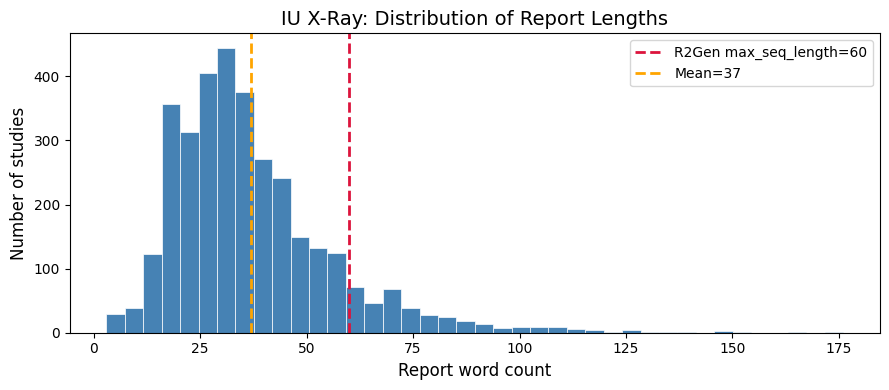

In [4]:
all_reports = [ex['report'] for s in ann for ex in ann[s]]
word_counts = [len(r.split()) for r in all_reports]

print(f'Report word count statistics:')
print(f'  Min    : {min(word_counts)}')
print(f'  Max    : {max(word_counts)}')
print(f'  Mean   : {np.mean(word_counts):.1f}')
print(f'  Median : {np.median(word_counts):.0f}')
print(f'  Std    : {np.std(word_counts):.1f}')
print(f'\nReports <= 60 words (R2Gen default max): {sum(w<=60 for w in word_counts)} ({100*sum(w<=60 for w in word_counts)/len(word_counts):.1f}%)')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(word_counts, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(60, color='crimson', linestyle='--', linewidth=2, label='R2Gen max_seq_length=60')
ax.axvline(np.mean(word_counts), color='orange', linestyle='--', linewidth=2, label=f'Mean={np.mean(word_counts):.0f}')
ax.set_xlabel('Report word count', fontsize=12)
ax.set_ylabel('Number of studies', fontsize=12)
ax.set_title('IU X-Ray: Distribution of Report Lengths', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'report_length_dist.png', dpi=150)
plt.show()

## 4. Vocabulary Statistics

In [5]:
# Only count train vocab (as R2Gen tokenizer does)
train_tokens = []
for ex in ann['train']:
    train_tokens.extend(ex['report'].lower().split())

counter = Counter(train_tokens)
vocab_full  = len(counter)
vocab_3plus = sum(1 for k, v in counter.items() if v >= 3)   # R2Gen threshold=3

print(f'Total unique tokens (train)       : {vocab_full:,}')
print(f'Vocab (freq >= 3, R2Gen default) : {vocab_3plus:,}')
print('\nTop 20 most common words:')
for word, cnt in counter.most_common(20):
    print(f'  {word:<20s} {cnt:>5}')

Total unique tokens (train)       : 2,484
Vocab (freq >= 3, R2Gen default) : 1,219

Top 20 most common words:
  no                    4629
  the                   4099
  are                   2784
  is                    2732
  of                    1974
  and                   1964
  acute                 1822
  pleural               1735
  or                    1703
  normal                1652
  xxxx                  1635
  heart                 1465
  there                 1420
  lungs                 1268
  focal                 1152
  size                  1074
  pulmonary             1040
  within                1025
  cardiopulmonary       1023
  in                     983


## 5. Sample Image Visualisation — Frontal + Lateral + Report

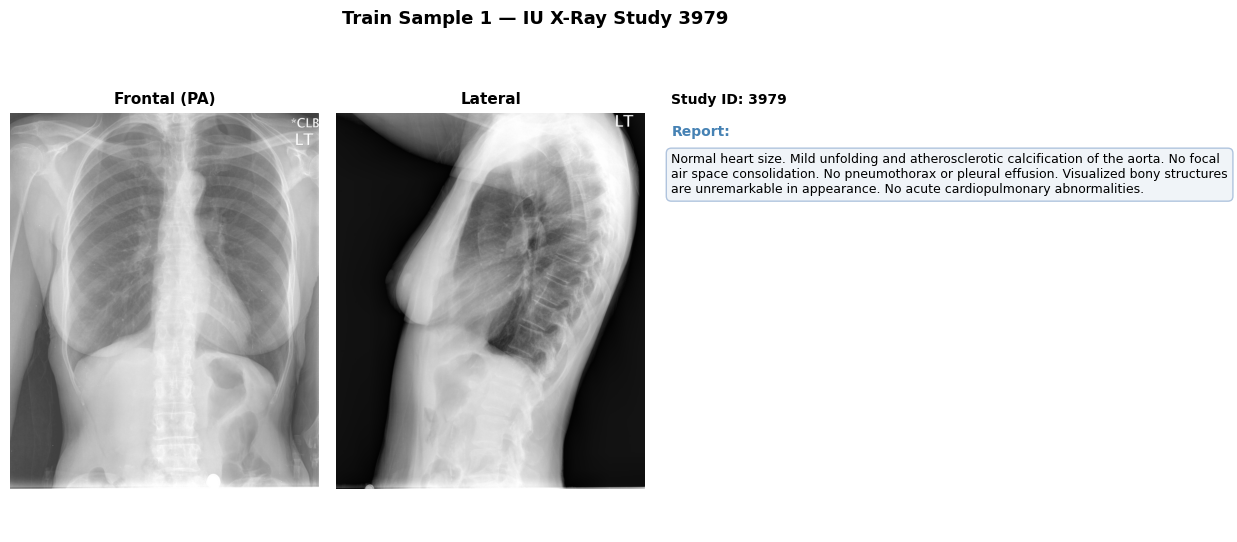

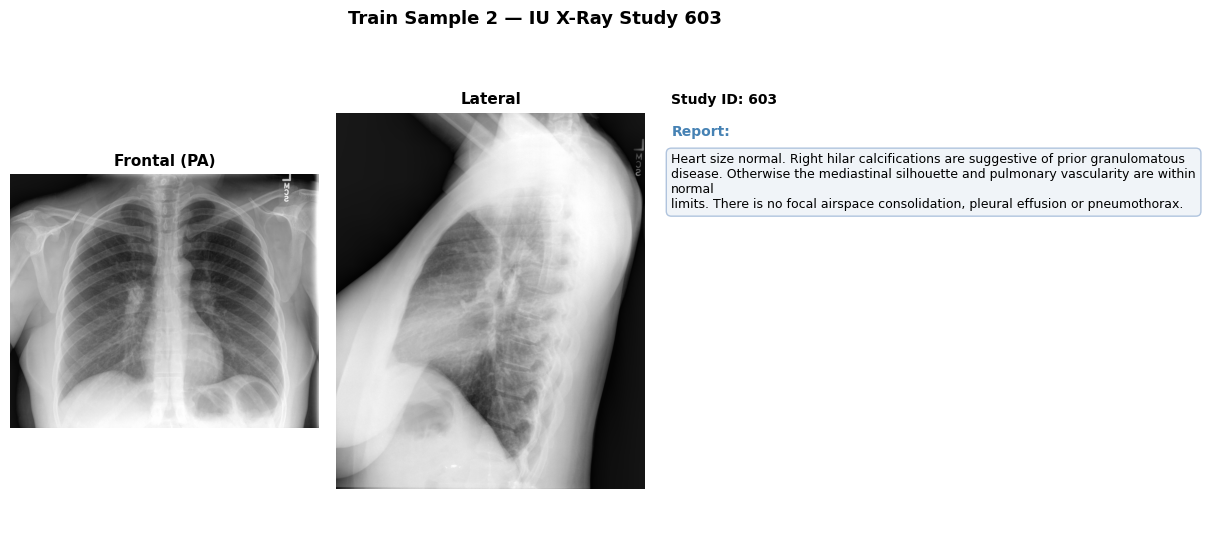

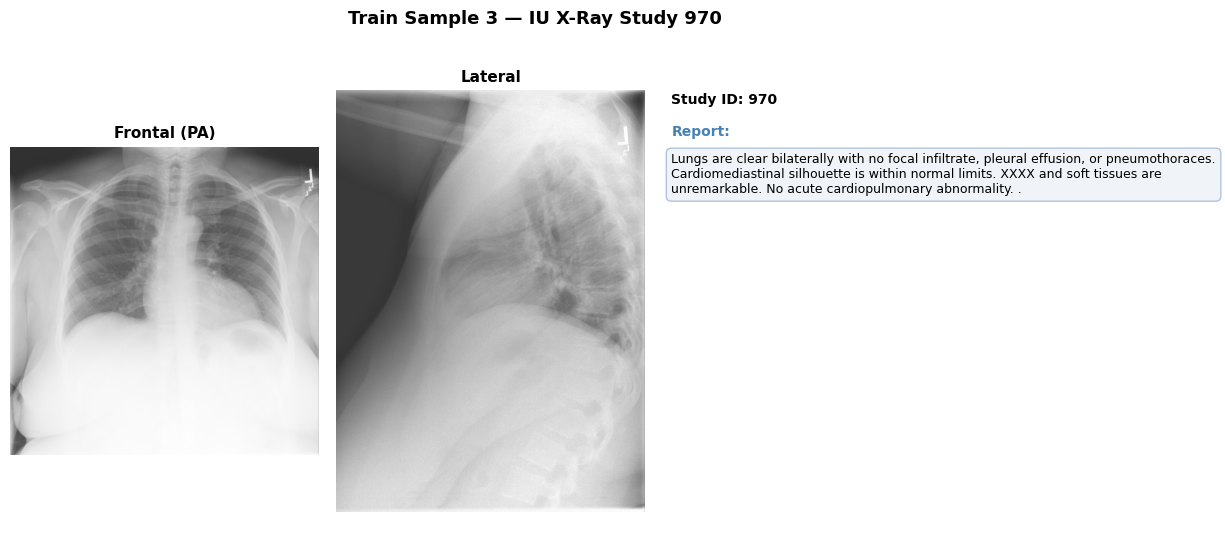

In [6]:
def show_sample(example, title_prefix=''):
    img_frontal = Image.open(IMAGE_DIR / example['image_path'][0]).convert('RGB')
    img_lateral = Image.open(IMAGE_DIR / example['image_path'][1]).convert('RGB')
    report_wrapped = textwrap.fill(example['report'], width=90)

    fig = plt.figure(figsize=(14, 6))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.4], wspace=0.05)

    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(img_frontal, cmap='gray')
    ax1.set_title('Frontal (PA)', fontsize=11, fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[1])
    ax2.imshow(img_lateral, cmap='gray')
    ax2.set_title('Lateral', fontsize=11, fontweight='bold')
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[2])
    ax3.axis('off')
    ax3.text(0.02, 0.95, f'Study ID: {example["id"]}',
             transform=ax3.transAxes, fontsize=10, fontweight='bold', va='top')
    ax3.text(0.02, 0.88, 'Report:',
             transform=ax3.transAxes, fontsize=10, fontweight='bold', va='top', color='steelblue')
    ax3.text(0.02, 0.82, report_wrapped,
             transform=ax3.transAxes, fontsize=9, va='top', wrap=True,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#f0f4f8', edgecolor='#b0c4de'))

    fig.suptitle(f'{title_prefix} — IU X-Ray Study {example["id"]}', fontsize=13, fontweight='bold')
    plt.savefig(DATA_DIR / f'sample_{example["id"]}.png', dpi=120, bbox_inches='tight')
    plt.show()

# Show 3 random samples from train set
samples = random.sample(ann['train'], 3)
for i, s in enumerate(samples):
    show_sample(s, title_prefix=f'Train Sample {i+1}')

## 6. Show 2 Samples from Val + 2 from Test

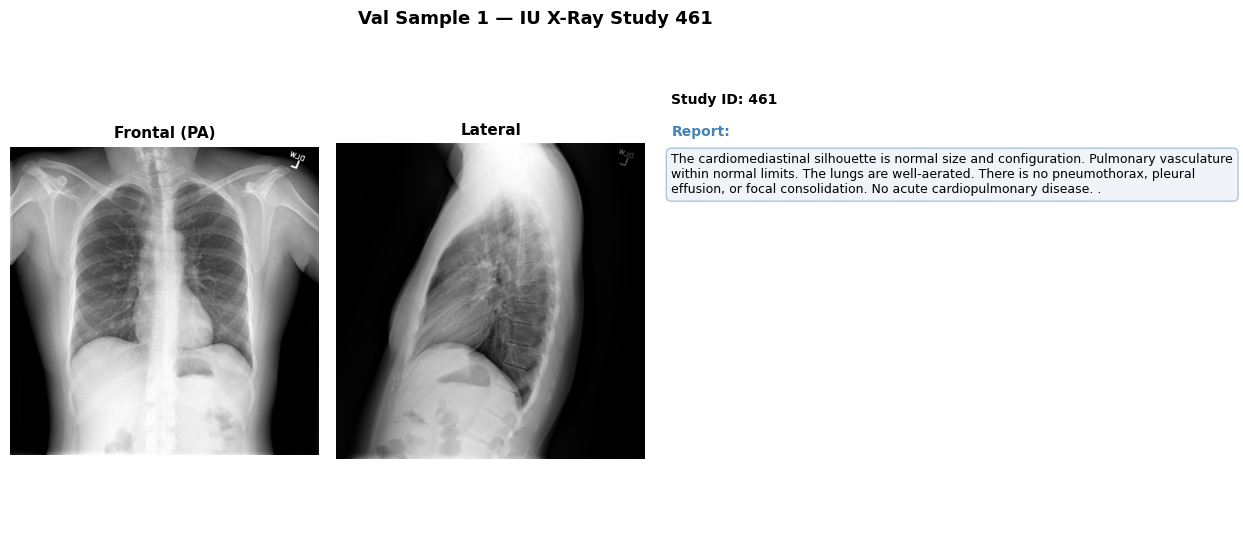

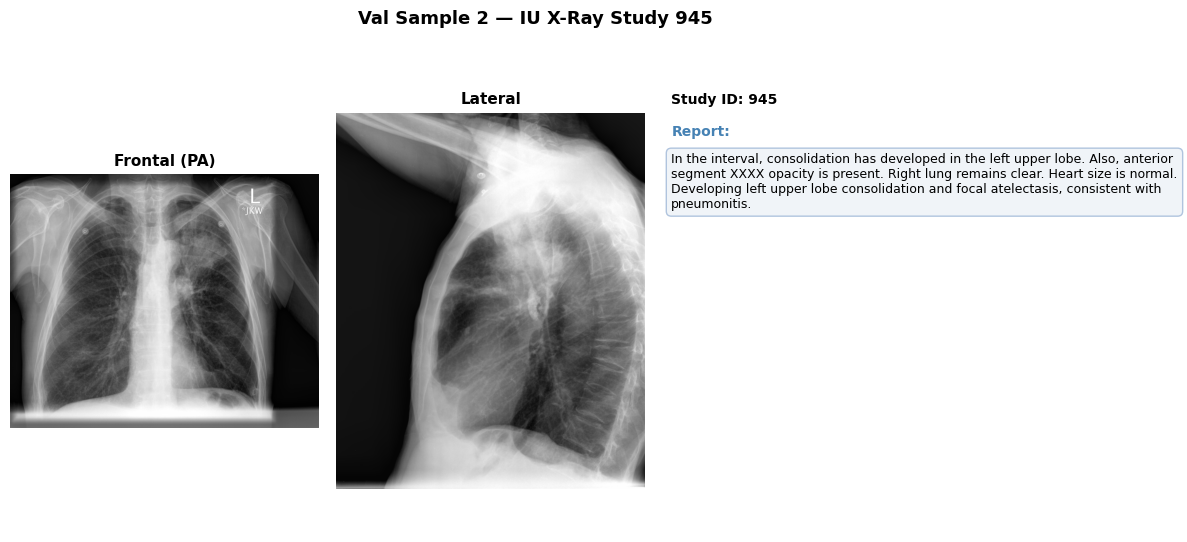

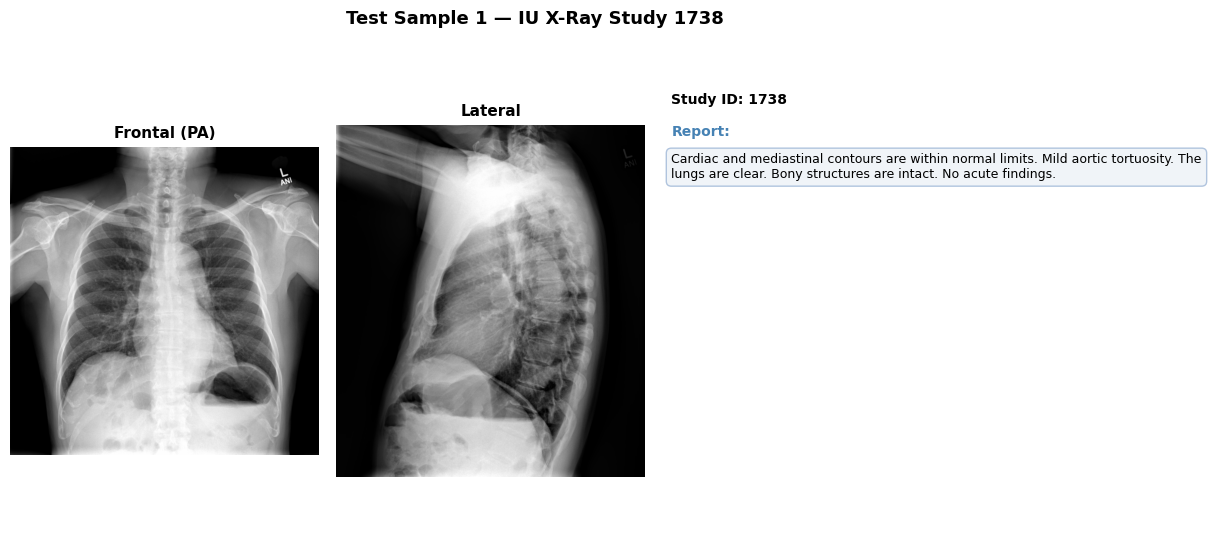

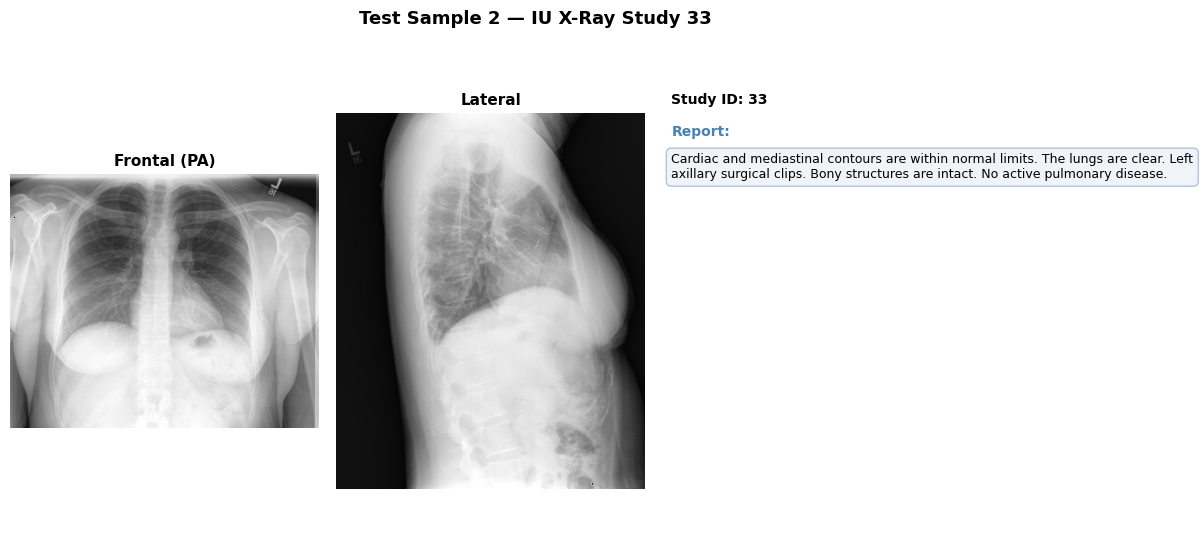

In [7]:
for split_name, split_data in [('Val', ann['val']), ('Test', ann['test'])]:
    picked = random.sample(split_data, 2)
    for i, s in enumerate(picked):
        show_sample(s, title_prefix=f'{split_name} Sample {i+1}')

## 7. Data Structure Sanity Check Summary

In [ ]:
# Verify every record has required R2Gen fields
REQUIRED = {'id', 'image_path', 'report'}
errors = []
for split in ('train', 'val', 'test'):
    for ex in ann[split]:
        missing_keys = REQUIRED - set(ex.keys())
        if missing_keys:
            errors.append(f"{split}/{ex.get('id','?')} missing keys: {missing_keys}")
        if not isinstance(ex.get('image_path', None), list) or len(ex['image_path']) != 2:
            errors.append(f"{split}/{ex.get('id','?')} image_path must be list of 2")
        if not ex.get('report', '').strip():
            errors.append(f"{split}/{ex.get('id','?')} empty report")

print('='*55)
print('  annotation.json Sanity Check')
print('='*55)
if errors:
    print(f'  FAILED - {len(errors)} errors found:')
    for e in errors[:10]:
        print('   ', e)
else:
    total = sum(len(ann[s]) for s in ann)
    print(f'  PASSED - all {total} records have correct R2Gen schema')
    print(f'  Fields validated: {REQUIRED}')
    print(f'  Split: train={len(ann["train"])} / val={len(ann["val"])} / test={len(ann["test"])}')
    avg_report_words = np.mean([len(ex["report"].split()) for s in ann for ex in ann[s]])
    print(f'  Avg report length: {avg_report_words:.1f} words')
    print(f'  Image pairs per study: 2 (frontal + lateral)')


  annotation.json Sanity Check
  PASSED - all 3376 records have correct R2Gen schema
  Fields validated: {'image_path', 'id', 'report'}
  Split: train=2364 / val=337 / test=675
  Avg report length: 37.0 words
  Image pairs per study: 2 (frontal + lateral)
Phase 2 - Step 1 & 2 COMPLETE!
